## Step 1: Import Required Libraries

In [660]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split ,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve


## Step 2: Load the Dataset

In [661]:
Loan_prediction_df = pd.read_csv('data/Loan_prediction.csv')
Loan_prediction_copy = Loan_prediction_df.copy()

## Step 3: Understand the Dataset

In [662]:
Loan_prediction_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [663]:
# Shape of dataset
print("\nShape of Dataset:", Loan_prediction_df.shape)

# Column names
print("\nColumns in Dataset:\n")
print(Loan_prediction_df.columns)

# Check missing values
print("\nMissing Values:\n")
print(Loan_prediction_df.isna().sum())

# Target values
print("\nTarget Values:")
print(Loan_prediction_df['Loan_Status'].value_counts())


Shape of Dataset: (614, 13)

Columns in Dataset:

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Missing Values:

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Target Values:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [664]:
Loan_prediction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [665]:
Loan_prediction_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [666]:
# check for duplicates
Loan_prediction_df.duplicated().sum()

np.int64(0)

## Step 4: EDA

Feature Cleaning

In [667]:
Loan_prediction_df.drop('Loan_ID', axis=1, inplace=True)

Target Distribution:

To check class imbalance.

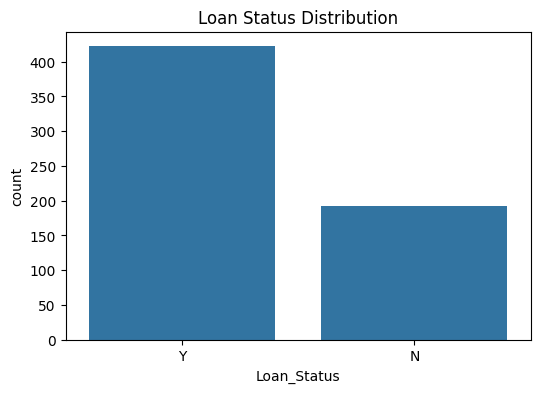

In [668]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=Loan_prediction_df)
plt.title('Loan Status Distribution')
plt.savefig('Images/loan_status_distribution.png')
plt.show()

Numerical Distributions:

In [669]:
num_cols = ['LoanAmount',
            'Loan_Amount_Term',
            'Credit_History',
            'ApplicantIncome',
            'CoapplicantIncome']

for col in num_cols:
    Loan_prediction_df[col] = Loan_prediction_df[col].fillna(Loan_prediction_df[col].median())

In [670]:
for col in num_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(Loan_prediction_df[col], kde=True)

    plt.title(col)
    # plt.show()
    plt.savefig(f'Images/{col}_distribution.png')
    plt.close()

In [671]:
for col in num_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x= Loan_prediction_df[col])

    plt.title(f'{col} Boxplot')
    # plt.show()
    plt.savefig(f'Images/{col}_boxplot.png')
    plt.close()

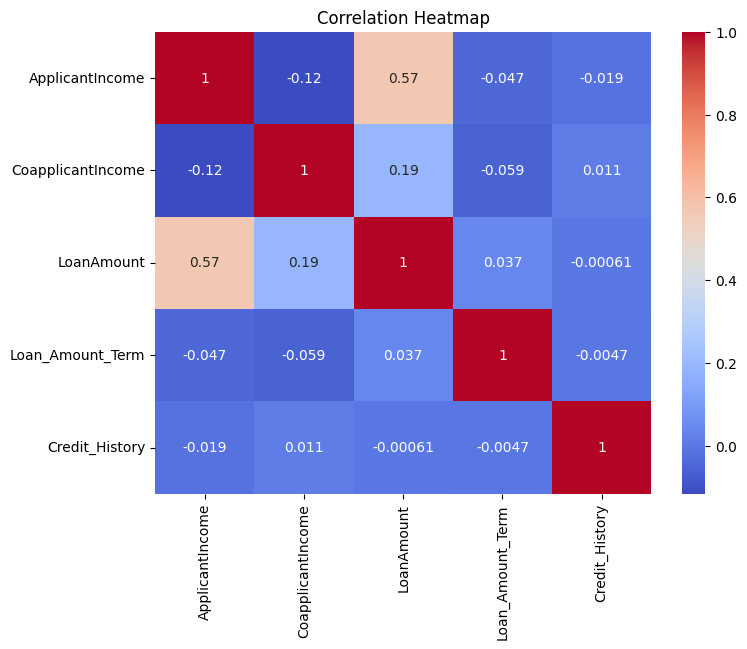

In [672]:
plt.figure(figsize=(8,6))

sns.heatmap(
    Loan_prediction_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.savefig('Images/correlation_heatmap.png')
plt.show()
plt.close()

In [673]:
cat_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Dependents'
]

for col in cat_cols:
    Loan_prediction_df[col] = Loan_prediction_df[col].fillna(Loan_prediction_df[col].mode()[0])

In [674]:
Loan_prediction_df['Dependents'] = Loan_prediction_df['Dependents'].replace('3+', 3)
Loan_prediction_df['Dependents'] = pd.to_numeric(Loan_prediction_df['Dependents'])

Categorical vs Loan Status

In [675]:

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        hue='Loan_Status',
        data=Loan_prediction_df
    )

    plt.savefig(f'Images/{col}_vs_LoanStatus.png')
    # plt.show()
    plt.close()

## Step 5: Define Features and Target Variable

Label encoding

In [676]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in Loan_prediction_df.select_dtypes( include=['object', 'string']).columns:
    Loan_prediction_df[col] = le.fit_transform(Loan_prediction_df[col])

In [677]:
# save cleaned dataset
Loan_prediction_df.to_csv('data/Loan_Prediction_Cleaned.csv',index=False)

In [678]:
X = Loan_prediction_df.drop('Loan_Status', axis=1)
Y = Loan_prediction_df['Loan_Status']

In [679]:
X.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
dtype: object

In [680]:
Loan_prediction_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [681]:
Loan_prediction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


In [682]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y # reduces the risk of biased performance estimates caused by uneven class distributions.
    # works for classification problems
)

In [683]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 6: Model Building 

In [684]:
lr = LogisticRegression()

lr.fit(X_train, Y_train)

y_pred_lr = lr.predict(X_test)

## Step 7: Model Evaluation 

#### Model Evaluation

In [685]:
# resuable function to compare diff model

def evaluate_model(model, X_test, Y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

    plt.figure(figsize=(8,5))
    plt.plot(fpr, tpr)

    plt.plot([0,1],[0,1],'--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.savefig('Images/ROC_Curve.png')
    plt.show()
    
    print("Accuracy :", accuracy_score(Y_test,y_pred))
    print("Precision:", precision_score(Y_test,y_pred))
    print("Recall   :", recall_score(Y_test,y_pred))
    print("F1 Score :", f1_score(Y_test,y_pred))
    print("ROC AUC  :", roc_auc_score(Y_test,y_prob))

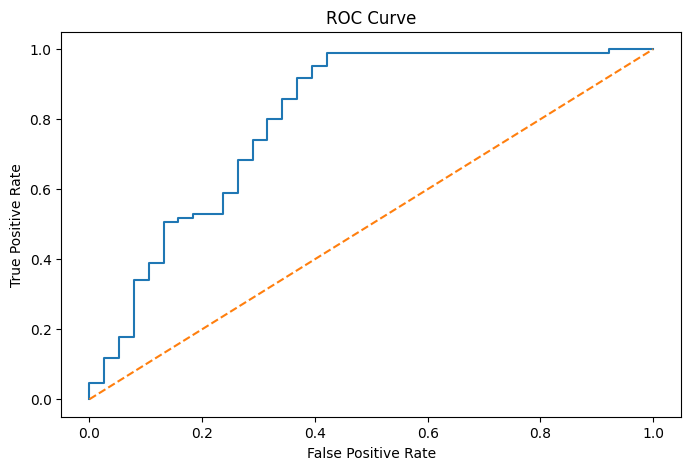

Accuracy : 0.8617886178861789
Precision: 0.84
Recall   : 0.9882352941176471
F1 Score : 0.9081081081081082
ROC AUC  : 0.8018575851393189


In [686]:
evaluate_model(lr, X_test, Y_test)

Confusion Matrix:



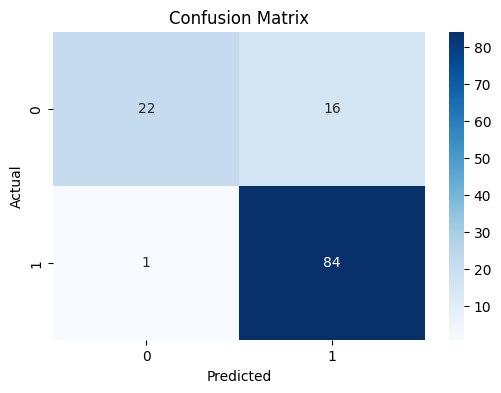

In [687]:
# Create confusion matrix

cm = confusion_matrix(Y_test, y_pred_lr)

print("Confusion Matrix:\n")

# Visualize confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('Images/confusion_matrix.png')
plt.show()


In [688]:
# Print classification report

report = classification_report(Y_test, y_pred_lr)

print(report)


              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [689]:
scores = cross_val_score(
    lr,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean CV Score:", scores.mean())

[0.7979798  0.80612245 0.81632653 0.78571429 0.7755102 ]
Mean CV Score: 0.7963306534735106


Feature Importance

In [690]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

              Feature  Coefficient
9      Credit_History     1.232589
1             Married     0.258466
2          Dependents     0.114775
10      Property_Area     0.047412
8    Loan_Amount_Term     0.003615
5     ApplicantIncome    -0.007706
7          LoanAmount    -0.037753
4       Self_Employed    -0.072812
0              Gender    -0.090795
6   CoapplicantIncome    -0.150906
3           Education    -0.182466


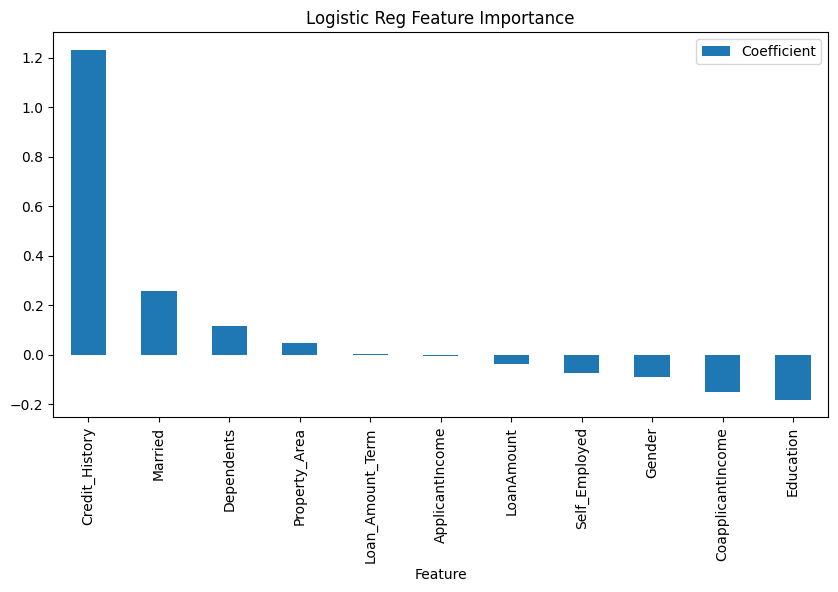

In [691]:
coef_df.plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5)
)

plt.title('Logistic Reg Feature Importance')
plt.show()

## Conclusion

The objective of this project was to develop a machine learning model capable of predicting loan approval status based on applicant demographics, financial information, and credit history.

The dataset was initially analyzed to understand its structure, identify missing values, and examine feature distributions. Missing values in categorical variables were handled using mode imputation, while numerical variables were imputed using the median to reduce the influence of outliers. The Loan_ID column was removed because it does not contribute to prediction. Categorical variables were encoded into numerical representations to make them suitable for machine learning algorithms.

Exploratory Data Analysis revealed that ApplicantIncome, CoapplicantIncome, and LoanAmount exhibited right-skewed distributions and contained outliers. Credit_History showed the strongest relationship with loan approval status. Feature selection using the Chi-Square test further confirmed that income-related variables, loan amount, and credit history had stronger associations with the target variable than demographic features such as Gender and Self_Employed status.

A Logistic Regression model was trained and evaluated using a stratified train-test split to preserve the original class distribution. The model achieved:

Accuracy: 86.18%

Precision: 84.00%

Recall: 98.82%

F1 Score: 90.81%

ROC-AUC: 0.802

The high recall indicates that the model successfully identifies most approved loan applications, while the strong F1 score demonstrates a good balance between precision and recall. Analysis of Logistic Regression coefficients showed that Credit_History was the most influential predictor of loan approval, highlighting the importance of an applicant's creditworthiness in lending decisions.

Overall, the project demonstrates a complete end-to-end machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, feature selection, model development, and performance evaluation. The resulting model can support financial institutions in making data-driven loan approval decisions while providing insights into the factors that most influence approval outcomes.